### NLP Project Of Drug Sentiment Analysis
#### Objective: Patient's Condition Classification Using Drug Reviews

#### 1.Understand the Dataset

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the dataset
df = pd.read_excel('drugsCom_raw.xlsx')

In [3]:
#dataset preview
print('Drugs Dataset Preview:')
df.head()

Drugs Dataset Preview:


,Unnamed: 0,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37


In [4]:
#dataset shape
print('The dataset shape is:',df.shape)

The dataset shape is: (161297, 7)


In [5]:
#dataset dtypes
print('Dataset Dtypes:')
df.dtypes

Dataset Dtypes:


Unnamed: 0              int64
drugName               object
condition              object
review                 object
rating                  int64
date           datetime64[ns]
usefulCount             int64
dtype: object

In [6]:
#stats summary
print('Basic Statistics Summary For Numerical Columns:')
df.describe()

Basic Statistics Summary For Numerical Columns:


,Unnamed: 0,rating,date,usefulCount
count,161297.000000,161297.000000,161297,161297.000000
mean,115923.585305,6.994377,2014-06-11 08:51:43.779983360,28.004755
min,2.000000,1.000000,2008-02-24 00:00:00,0.000000
25%,58063.000000,5.000000,2012-04-12 00:00:00,6.000000
50%,115744.000000,8.000000,2015-06-09 00:00:00,16.000000
75%,173776.000000,10.000000,2016-08-19 00:00:00,36.000000
max,232291.000000,10.000000,2017-12-12 00:00:00,1291.000000
std,67004.445170,3.272329,NaN,36.403742


In [9]:
#check duplicates
duplicates = df.duplicated().sum()

if duplicates == 0:
    print('No duplicates found!')
else:
    print(f'{duplicates} duplicates found.')
    df = df.drop_duplicates(keep='first')
    print(f'{duplicates} duplicates dropped.')

No duplicates found!


In [10]:
#check missing %
def check_missing(df):
       missing_data = df.isnull().sum()

       missing_df = pd.DataFrame({
             'Feature' : df.columns,
             'Data Type' : [df[col].dtype for col in df.columns],
             'Missing_col' : missing_data.values,
              'Missing_%' : (missing_data.values / len(df)) * 100
             })

       missing_df_summary = missing_df[missing_df['Missing_col']>0]

       missing_df_summary = missing_df_summary.sort_values(by='Missing_%',ascending=False)

       if len(missing_df_summary) > 0:
              display(missing_df_summary.style.background_gradient(cmap='Reds',subset='Missing_%'))
       else:
             print('No Missing Values.')
       return missing_df_summary   

missing_df_summary = check_missing(df)    

,Feature,Data Type,Missing_col,Missing_%
2,condition,object,899,0.557357


In [11]:
#drop na in condition columns
df = df.dropna(subset=['condition'])

In [12]:
#drop unnecessary columns
df = df.drop(columns=['Unnamed: 0','usefulCount'])

#### 1.Missing values in condition column & only 0.5% of rows had missing condition values, so for sentiment modeling, dropped it to keep the dataset clean. 
#### 2.Dropped unnecessary columns like unamed: 0 & usefulcount

In [13]:
#check the missing values after dropping na
missing_df_summary = check_missing(df)    

No Missing Values.


In [14]:
#check the shape after dropping na
print('The dataset shape is:',df.shape)

The dataset shape is: (160398, 5)


In [15]:
#label distribution
print('Review Count\n',df['review'].value_counts())
print('Review Percentage\n',df['review'].value_counts(normalize=True)*100)

Review Count
 review
"Good"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               33
"Great"                                                                                                                                                                                                    

#### 2.Text Preprocessing

In [16]:
#import libraries
import re
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.stem import WordNetLemmatizer , PorterStemmer
from nltk.corpus import stopwords

In [17]:
''' nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet') 
'''

" nltk.download('punkt')\nnltk.download('stopwords')\nnltk.download('wordnet') \n"

In [18]:
def preprocess_review(text,remove_stopwords=True,use_lemmatize=True,use_stemming=False):
    #remove special chars / tags html
    text = re.sub(r'<.*?/>','',text)
    text = re.sub(r'https\s+|www\.\s+','',text)
    text = re.sub(r'[^\w\s]','',text)
    #lowercase
    text = str(text).lower()
    #tokenize
    tokens = word_tokenize(text)
    #stopword removal
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [w for w in tokens if w not in stop_words]

    if use_lemmatize:
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return tokens    

In [19]:
df['processed_tokens'] = df['review'].apply(preprocess_review) #applying preprocess function
#converting tokens to clean text
df['processed_text'] = df['processed_tokens'].apply(lambda x: " ".join(x))

In [20]:
df['processed_text'].head()

0    side effect take combination bystolic 5 mg fis...
1    son halfway fourth week intuniv became concern...
2    used take another oral contraceptive 21 pill c...
3    first time using form birth control i039m glad...
4    suboxone completely turned life around feel he...
Name: processed_text, dtype: object

#### 3.Basic Text Statistics

In [21]:
targeted_condition = ["Depression", "High Blood Pressure", "Diabetes, Type 2"]
df_condt = df[df['condition'].isin(targeted_condition)]
df_condt.head()

,drugName,condition,review,rating,date,processed_tokens,processed_text
11,L-methylfolate,Depression,"""I have taken anti-depressants for years, with...",10,2017-03-09,"[taken, antidepressant, year, improvement, mos...",taken antidepressant year improvement mostly m...
31,Sertraline,Depression,"""1 week on Zoloft for anxiety and mood swings....",8,2011-05-07,"[1, week, zoloft, anxiety, mood, swing, take, ...",1 week zoloft anxiety mood swing take 50mg mor...
44,Venlafaxine,Depression,"""my gp started me on Venlafaxine yesterday to ...",4,2016-04-27,"[gp, started, venlafaxine, yesterday, help, de...",gp started venlafaxine yesterday help depressi...
50,Dulaglutide,"Diabetes, Type 2","""Hey Guys, It&#039;s been 4 months since my l...",10,2017-10-24,"[hey, guy, it039s, 4, month, since, last, post...",hey guy it039s 4 month since last post wanted ...
67,Effexor XR,Depression,"""This medicine saved my life. I was at my wits...",10,2013-06-20,"[medicine, saved, life, wit, end, antidepressa...",medicine saved life wit end antidepressant rea...


In [22]:
#text length distibution
df_condt['char_len'] = df_condt['review'].apply(len)
df_condt['word_len'] = df_condt['review'].apply(lambda x: len(word_tokenize(x)))
df_condt['sent_len'] = df_condt['review'].apply(lambda x: len(sent_tokenize(x)))

C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\3308924067.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_condt['char_len'] = df_condt['review'].apply(len)
C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\3308924067.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_condt['word_len'] = df_condt['review'].apply(lambda x: len(word_tokenize(x)))
C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\3308924067.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

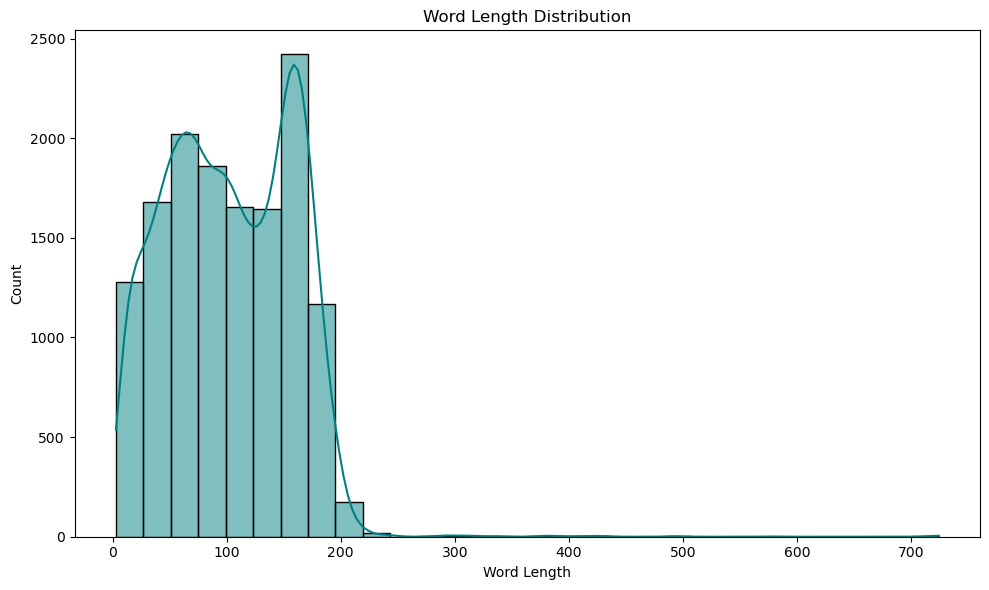

In [23]:
#plot the histogram for word length
plt.figure(figsize=(10,6))
plt.title('Word Length Distribution')
sns.histplot(data=df_condt['word_len'],bins=30,kde=True,color='teal')
plt.xlabel('Word Length')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [24]:
import nltk
#nltk.download('vader_lexicon')

In [25]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

In [26]:
df_condt['sentiment_score'] = df_condt['processed_text'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_condt['sentiment_class'] = df_condt['sentiment_score'].apply(lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral'))

C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\563153302.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_condt['sentiment_score'] = df_condt['processed_text'].apply(lambda x: sia.polarity_scores(x)['compound'])
C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\563153302.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_condt['sentiment_class'] = df_condt['sentiment_score'].apply(lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral'))


In [27]:
df_condt.groupby('sentiment_class')['word_len'].mean()

sentiment_class
Negative    108.691078
Neutral      63.482866
Positive    100.227154
Name: word_len, dtype: float64

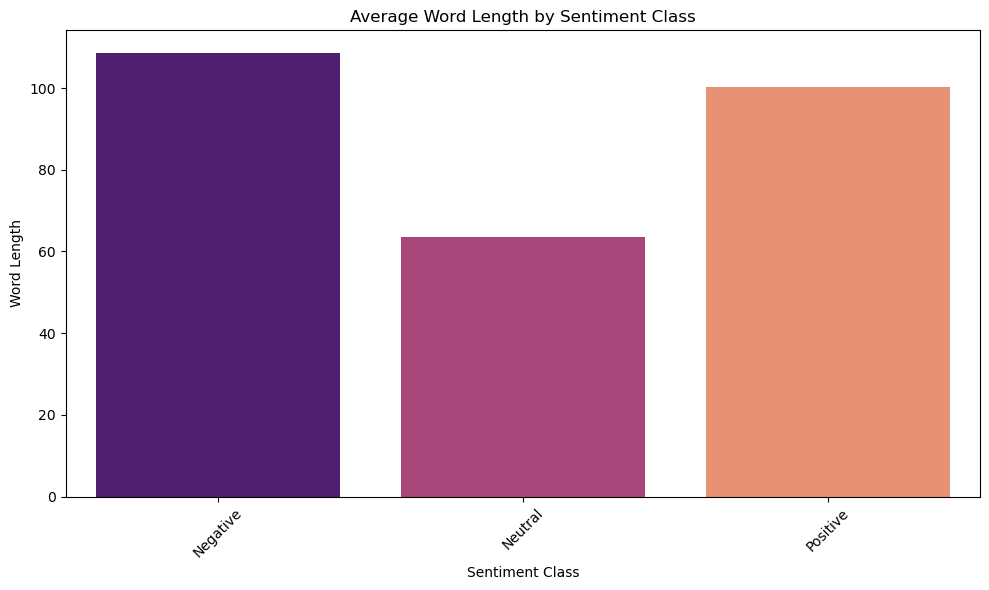

In [28]:
#plot the barplot for Average Word Length by Sentiment Class
aveg_metrics_df = df_condt.groupby('sentiment_class')['word_len'].mean().reset_index()
plt.figure(figsize=(10,6))
plt.title('Average Word Length by Sentiment Class')
sns.barplot(data=aveg_metrics_df,x='sentiment_class',y='word_len',palette='magma',hue='sentiment_class',legend=False)
plt.xlabel('Sentiment Class')
plt.ylabel('Word Length')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
#vocabulary size
all_words = [word.lower() for review in df_condt['review'] for word in review.split()]
vocab_size = len(set(all_words))
print('Vocabulary size:',vocab_size)

Vocabulary size: 35844


In [30]:
#Top - N Frequent words
from collections import Counter
top_words = {}
for sentiment in df_condt['sentiment_class'].unique():
    words = [w for tokens in df_condt[df_condt['sentiment_class']==sentiment]['processed_tokens'] for w in tokens]
    top_words[sentiment] = Counter(words).most_common(20)

print('Top Positive Words in Targeted Condition Columns:',top_words['Positive'],'\n')    
print('Top Negative Words in Targeted Condition Columns:',top_words['Negative'],'\n')  
print('Top Neutral Words in Targeted Condition Columns:',top_words['Neutral'],'\n')  

Top Positive Words in Targeted Condition Columns: [('effect', 3108), ('day', 2939), ('side', 2824), ('feel', 2713), ('week', 2612), ('year', 2421), ('taking', 2319), ('month', 2176), ('like', 1955), ('i039m', 1949), ('started', 1853), ('better', 1724), ('i039ve', 1716), ('medication', 1686), ('take', 1591), ('time', 1559), ('first', 1552), ('life', 1533), ('depression', 1492), ('medicine', 1436)] 

Top Negative Words in Targeted Condition Columns: [('day', 4232), ('depression', 3991), ('effect', 3467), ('week', 3323), ('year', 3284), ('taking', 3248), ('side', 3176), ('month', 2705), ('feel', 2585), ('time', 2377), ('started', 2358), ('anxiety', 2322), ('medication', 2218), ('i039m', 2104), ('take', 1971), ('first', 1941), ('doctor', 1877), ('i039ve', 1855), ('blood', 1822), ('like', 1820)] 

Top Neutral Words in Targeted Condition Columns: [('effect', 236), ('side', 227), ('day', 202), ('year', 192), ('week', 191), ('taking', 171), ('month', 150), ('depression', 141), ('medication', 1

#### 4.Class Distribution & Balance

In [31]:
#check imbalance
#class per count
class_count = df_condt['sentiment_class'].value_counts()
print(class_count)

sentiment_class
Negative    7196
Positive    6106
Neutral      642
Name: count, dtype: int64


In [32]:
class_percent = df_condt['sentiment_class'].value_counts(normalize=True)*100
print(class_percent)

sentiment_class
Negative    51.606426
Positive    43.789443
Neutral      4.604131
Name: proportion, dtype: float64


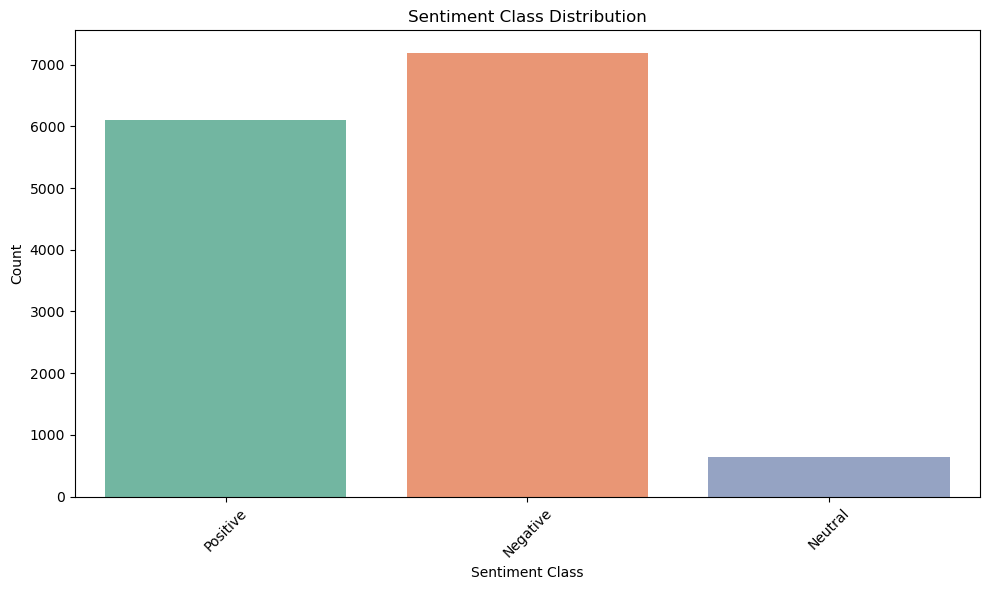

In [33]:
#visualizing the sentiment class
plt.figure(figsize=(10,6))
plt.title('Sentiment Class Distribution')
sns.countplot(data=df_condt,x='sentiment_class',hue='sentiment_class',legend=False,palette='Set2')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

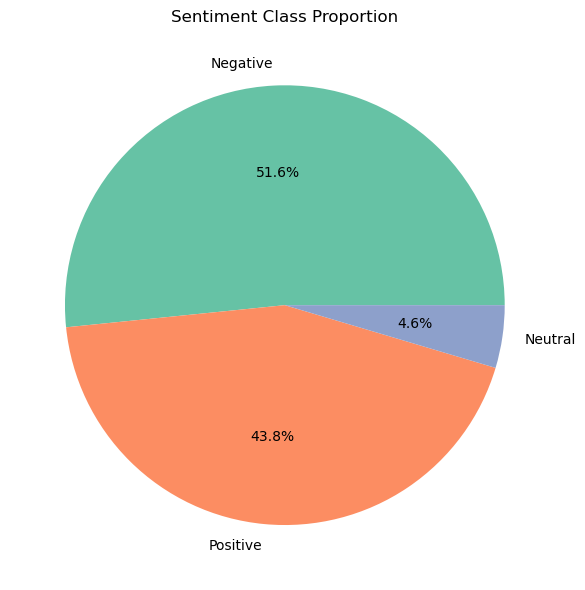

In [34]:
#pie chart
plt.figure(figsize=(10,6))
plt.title('Sentiment Class Proportion')
df_condt['sentiment_class'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66c2a5','#fc8d62','#8da0cb'])
plt.ylabel("")
plt.tight_layout()
plt.show()

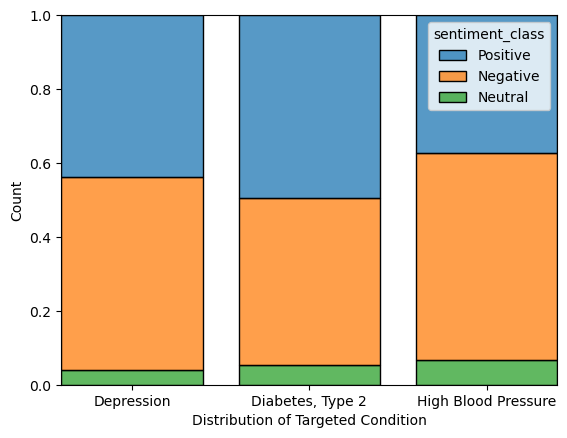

In [35]:
#stratify metadata
sns.histplot(data=df_condt, x='condition', hue='sentiment_class', multiple='fill', shrink=.8)
plt.xlabel('Distribution of Targeted Condition')
plt.show()

#### 5.Word-Level Analysis

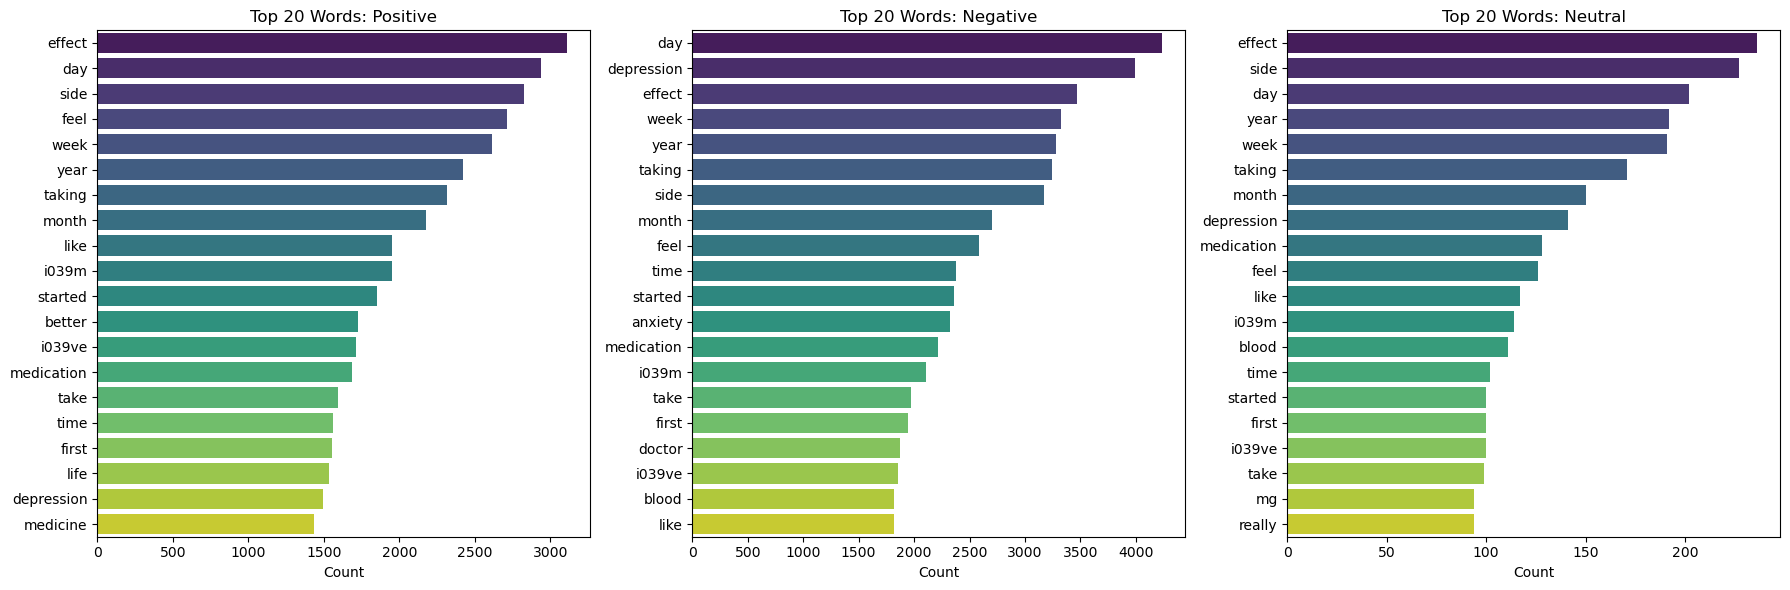

In [36]:
#Top - N Frequent words for targeted columns & --------plotting the graph code is above
fig, axes = plt.subplots(1, len(top_words), figsize=(18, 6))

for i, (sentiment, counts) in enumerate(top_words.items()):
    # Convert (word, count) tuples into a DataFrame
    df_plot = pd.DataFrame(counts, columns=['Word', 'Frequency'])
    sns.barplot(data=df_plot, x='Frequency', y='Word', ax=axes[i],legend=False, hue='Word' ,palette='viridis')
    axes[i].set_title(f'Top 20 Words: {sentiment}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

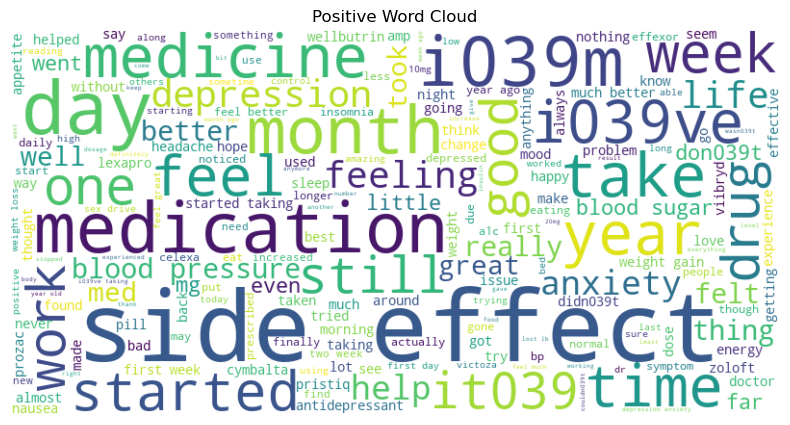

In [37]:
#generating wordcloud 
from wordcloud import WordCloud

def generate_cloud(sentiment):
    # Join all tokens into one big string
    text = " ".join([" ".join(tokens) for tokens in df_condt[df_condt['sentiment_class'] == sentiment]['processed_tokens']])
    cloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(cloud, interpolation='bilinear') #smooth the image when displaying it
    plt.axis('off')
    plt.title(f'{sentiment} Word Cloud')
    plt.show()
#generating wordcloud for targeted condition for positive
generate_cloud('Positive')

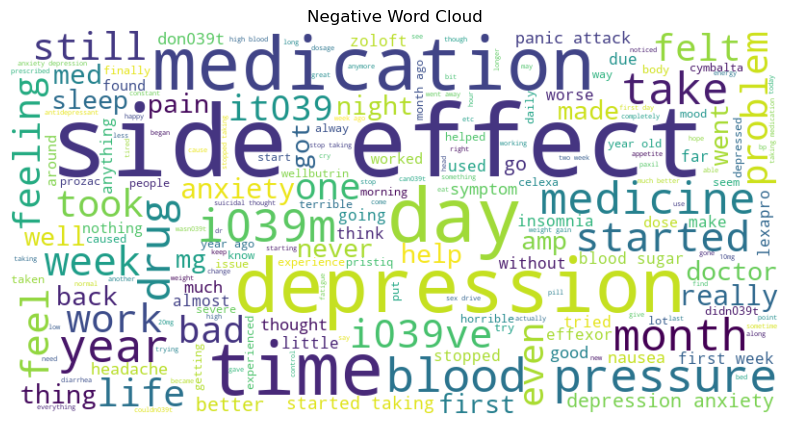

In [38]:
#generating wordcloud for targeted condition for negative
generate_cloud('Negative')

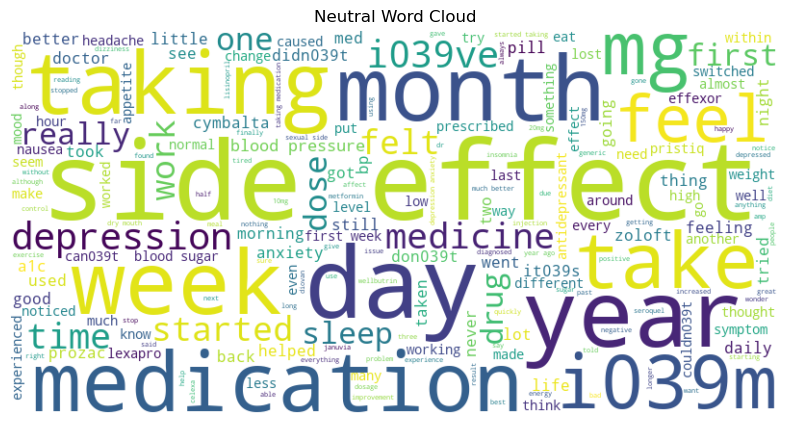

In [39]:
#generating wordcloud for targeted condition for neutral
generate_cloud('Neutral')

In [40]:
#N-grams for targeted condition
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_k=10):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

# Convert tokens back to strings for Vectorizer
corpus = df_condt['processed_tokens'].apply(lambda x: " ".join(x))
print("Top Bigrams:", get_top_ngrams(df_condt['processed_text'], n=2))

Top Bigrams: [('side effect', np.int64(5840)), ('blood pressure', np.int64(1934)), ('feel like', np.int64(1037)), ('started taking', np.int64(898)), ('blood sugar', np.int64(893)), ('depression anxiety', np.int64(678)), ('first week', np.int64(651)), ('much better', np.int64(636)), ('weight gain', np.int64(633)), ('year ago', np.int64(561))]


In [41]:
#TF-IDF scores
#extracting negative,poisitive & neutral cleantexts
neg_text = df_condt[df_condt['sentiment_class'] == 'Negative']['processed_text']
pos_text = df_condt[df_condt['sentiment_class'] == 'Positive']['processed_text']
neu_text = df_condt[df_condt['sentiment_class'] == 'Neutral']['processed_text']

In [42]:
print('Unique sentiment:',df_condt['sentiment_class'].unique())
#print sentiment review per class
print('Negative Review:',len(neg_text))
print('Positive Review:',len(pos_text))
print('Neutral Review:',len(neu_text))

Unique sentiment: ['Positive' 'Negative' 'Neutral']
Negative Review: 7196
Positive Review: 6106
Neutral Review: 642


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=1, max_df=1.0,stop_words=None) #min_df->appear atleast one document #max_df->appear upto 100% 
tfidf_matrix = vectorizer.fit_transform(df_condt['processed_text'])
features = vectorizer.get_feature_names_out()

#Compute mean TF-IDF per sentiment
pos_scores = tfidf_matrix[(df_condt['sentiment_class'] == "Positive").values].mean(axis=0).A1
neg_scores = tfidf_matrix[(df_condt['sentiment_class'] == "Negative").values].mean(axis=0).A1
neu_scores = tfidf_matrix[(df_condt['sentiment_class'] == "Neutral").values].mean(axis=0).A1

#Extract top discriminative words
top_pos = pd.Series(pos_scores, index=features).sort_values(ascending=False).head(10)
top_neg = pd.Series(neg_scores, index=features).sort_values(ascending=False).head(10)
top_neu = pd.Series(neu_scores, index=features).sort_values(ascending=False).head(10)

print("\nPositive discriminative words:\n", top_pos)
print("\nNegative discriminative words:\n", top_neg)
print("\nNeutral discriminative words:\n", top_neu)


Positive discriminative words:
 effect         0.016611
feel           0.015782
side           0.015630
side effect    0.015091
day            0.014913
week           0.014309
year           0.013694
taking         0.013021
great          0.012980
good           0.012927
dtype: float64

Negative discriminative words:
 depression     0.018937
day            0.017415
effect         0.014867
taking         0.014867
week           0.014537
year           0.014205
side           0.014183
side effect    0.013664
month          0.012785
anxiety        0.012662
dtype: float64

Neutral discriminative words:
 effect         0.022408
side           0.021923
side effect    0.021663
work           0.015280
year           0.013191
taking         0.012294
life           0.011615
day            0.011338
helped         0.010902
week           0.010869
dtype: float64


In [44]:
#dataset preview till now
df_condt.head()

,drugName,condition,review,rating,date,processed_tokens,processed_text,char_len,word_len,sent_len,sentiment_score,sentiment_class
11,L-methylfolate,Depression,"""I have taken anti-depressants for years, with...",10,2017-03-09,"[taken, antidepressant, year, improvement, mos...",taken antidepressant year improvement mostly m...,456,94,6,0.5994,Positive
31,Sertraline,Depression,"""1 week on Zoloft for anxiety and mood swings....",8,2011-05-07,"[1, week, zoloft, anxiety, mood, swing, take, ...",1 week zoloft anxiety mood swing take 50mg mor...,271,58,5,0.2960,Positive
44,Venlafaxine,Depression,"""my gp started me on Venlafaxine yesterday to ...",4,2016-04-27,"[gp, started, venlafaxine, yesterday, help, de...",gp started venlafaxine yesterday help depressi...,711,155,2,-0.6908,Negative
50,Dulaglutide,"Diabetes, Type 2","""Hey Guys, It&#039;s been 4 months since my l...",10,2017-10-24,"[hey, guy, it039s, 4, month, since, last, post...",hey guy it039s 4 month since last post wanted ...,767,175,7,0.3400,Positive
67,Effexor XR,Depression,"""This medicine saved my life. I was at my wits...",10,2013-06-20,"[medicine, saved, life, wit, end, antidepressa...",medicine saved life wit end antidepressant rea...,568,119,8,0.8101,Positive


#### 6.Lexical & Linguistic Features

C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\3794429636.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_depression['lexicon_scores'] = df_depression['review'].astype(str).apply(lambda x: sid.polarity_scores(x)['compound'])


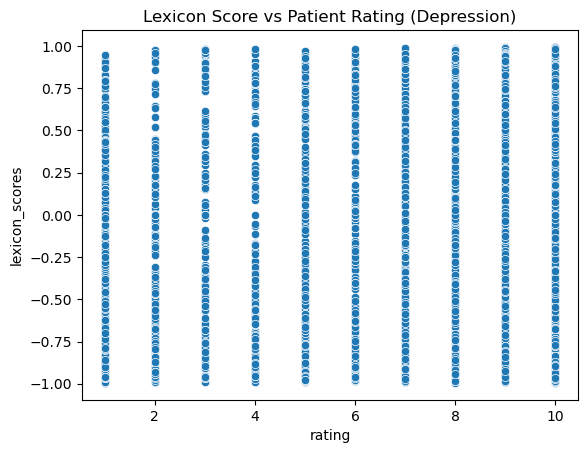

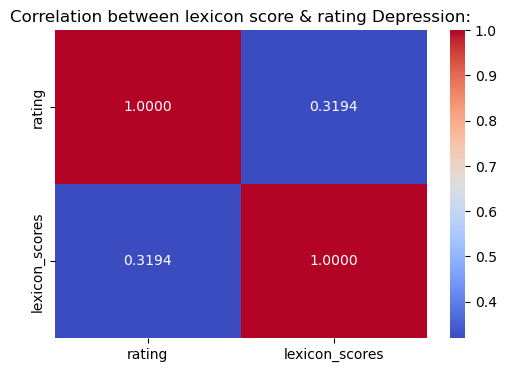

In [45]:
#Sentiment lexicon check for depression
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()
#lexicon score for depression
df_depression = df_condt[df_condt['condition']=='Depression']
df_depression['lexicon_scores'] = df_depression['review'].astype(str).apply(lambda x: sid.polarity_scores(x)['compound'])

#compairing lexicon score vs rating
sns.scatterplot(data=df_depression,x='rating',y='lexicon_scores')
plt.title("Lexicon Score vs Patient Rating (Depression)")
plt.show()

#heatmap
plt.figure(figsize=(6,4))
plt.title("Correlation between lexicon score & rating Depression:")
sns.heatmap(df_depression[['rating','lexicon_scores']].corr(),annot=True,fmt='.4f',cmap='coolwarm')
plt.show()

C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\1321352384.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Diabetes['lexicon_scores'] = df_Diabetes['review'].astype(str).apply(lambda x: sid.polarity_scores(x)['compound'])


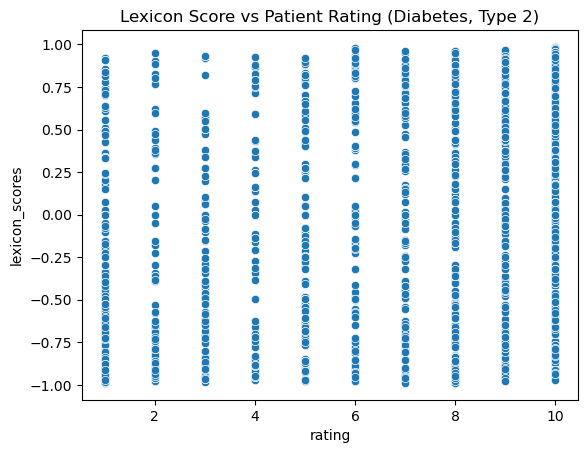

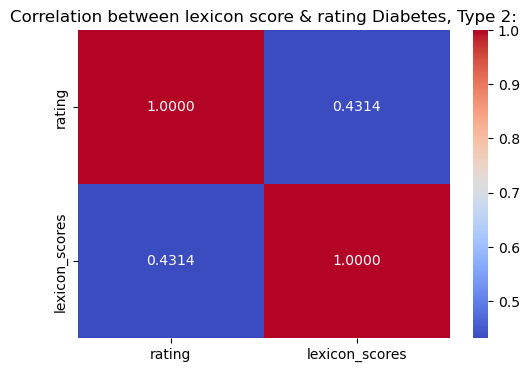

In [46]:
#lexicon score for Diabetes, Type 2
df_Diabetes = df_condt[df_condt['condition'] == 'Diabetes, Type 2']
df_Diabetes['lexicon_scores'] = df_Diabetes['review'].astype(str).apply(lambda x: sid.polarity_scores(x)['compound'])

#compairing lexicon score vs rating
sns.scatterplot(data=df_Diabetes,x='rating',y='lexicon_scores')
plt.title("Lexicon Score vs Patient Rating (Diabetes, Type 2)")
plt.show()

#heatmap
plt.figure(figsize=(6,4))
plt.title("Correlation between lexicon score & rating Diabetes, Type 2:")
sns.heatmap(df_Diabetes[['rating','lexicon_scores']].corr(),annot=True,fmt='.4f',cmap='coolwarm')
plt.show()

C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\2562615153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bp['lexicon_scores'] = df_bp['review'].astype(str).apply(lambda x: sid.polarity_scores(x)['compound'])


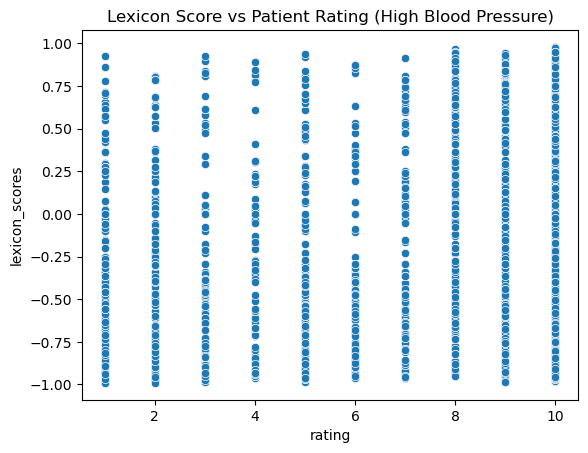

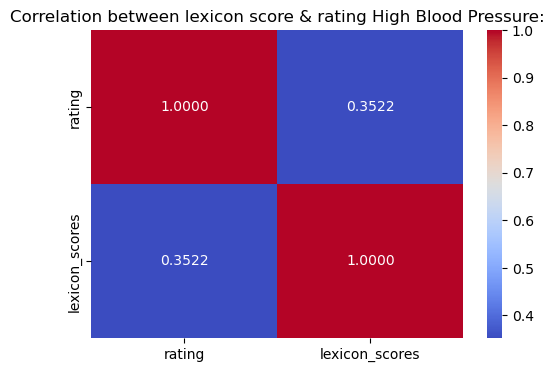

In [47]:
#lexicon score for High Blood Pressure
df_bp = df_condt[df_condt['condition'] == 'High Blood Pressure']
df_bp['lexicon_scores'] = df_bp['review'].astype(str).apply(lambda x: sid.polarity_scores(x)['compound'])

#compairing lexicon score vs rating
sns.scatterplot(data=df_bp,x='rating',y='lexicon_scores')
plt.title("Lexicon Score vs Patient Rating (High Blood Pressure)")
plt.show()

#heatmap
plt.figure(figsize=(6,4))
plt.title("Correlation between lexicon score & rating High Blood Pressure:")
sns.heatmap(df_bp[['rating','lexicon_scores']].corr(),annot=True,fmt='.4f',cmap='coolwarm')
plt.show()

In [48]:
#negation handling depression
import html
negations = ["not","never","no","n't"]

df_depression['clean_review'] = df_depression['review'].astype(str).apply(html.unescape)

def count_negations(text):
    clean_text = html.unescape(str(text))
    # Lowercase
    clean_text = clean_text.lower()
    # Tokenize
    tokens = word_tokenize(clean_text)
    # Count negations
    return sum(1 for t in tokens if t in negations)

df_depression['neg_count'] = df_depression['clean_review'].apply(count_negations)

print(df_depression[['clean_review','neg_count']].head(10))

C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\1922194717.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_depression['clean_review'] = df_depression['review'].astype(str).apply(html.unescape)


                                          clean_review  neg_count
11   "I have taken anti-depressants for years, with...          2
31   "1 week on Zoloft for anxiety and mood swings....          0
44   "my gp started me on Venlafaxine yesterday to ...          0
67   "This medicine saved my life. I was at my wits...          2
81   "Started taking it and I slept well at night a...          1
96   "Intake Effexor XR 375 mg, and lorazepam for d...          0
143  "This medication is amazing! After 3 days of b...          1
150  "My genius psychiatrist started me on this dru...          1
153  "I was really glad that I experienced none of ...          1
169  "This drug causes persistent nausea in some us...          2


C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\1922194717.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_depression['neg_count'] = df_depression['clean_review'].apply(count_negations)


In [49]:
#negation handling for diabetes
import html
negations = ["not","never","no","n't"]

df_Diabetes['clean_review'] = df_Diabetes['review'].astype(str).apply(html.unescape)

def count_negations(text):
    clean_text = html.unescape(str(text))
    # Lowercase
    clean_text = clean_text.lower()
    # Tokenize
    tokens = word_tokenize(clean_text)
    # Count negations
    return sum(1 for t in tokens if t in negations)

df_Diabetes['neg_count'] = df_Diabetes['clean_review'].apply(count_negations)

print(df_Diabetes[['clean_review','neg_count']].head(10))

C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\1378860025.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Diabetes['clean_review'] = df_Diabetes['review'].astype(str).apply(html.unescape)


                                          clean_review  neg_count
50   "Hey Guys,  It's been 4 months since my last p...          1
146  "I was recently referred to a endocrinologist ...          5
182  "have only been on victorza for a few days.  I...          1
187  "I have been taking Jardiance for just over a ...          2
223  "I've been on Victoza for 13 days and have los...          0
251  "I have only been on Victoza for less than a w...          2
256  "Started this last night. I have zero appetite...          4
271  "I was on Bydureon for about 2 months, I reall...          0
281  "Within 2 weeks saw blood glucose more than ha...          3
288  "I have been a type 2 diabetic for 10 yrs now....          0


C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\1378860025.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Diabetes['neg_count'] = df_Diabetes['clean_review'].apply(count_negations)


In [50]:
#negation handling for bp
import html
negations = ["not","never","no","n't"]

df_bp['clean_review'] = df_bp['review'].astype(str).apply(html.unescape)

def count_negations(text):
    clean_text = html.unescape(str(text))
    # Lowercase
    clean_text = clean_text.lower()
    # Tokenize
    tokens = word_tokenize(clean_text)
    # Count negations
    return sum(1 for t in tokens if t in negations)

df_bp['neg_count'] = df_bp['clean_review'].apply(count_negations)

print(df_bp[['clean_review','neg_count']].head(10))

C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\274834974.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bp['clean_review'] = df_bp['review'].astype(str).apply(html.unescape)


                                          clean_review  neg_count
104  "My blood pressure has been around 160/100. Do...          0
185  "I'm a 27 year old white male in good shape bu...          3
205  "I have been on metoprolol er 12.5mg since Sep...          4
363  "Using this for parasomnia, bph and bp. Kind o...          0
447  "I took Lopressor for 24 years it worked very ...          1
668  "I was just prescribed this medicine 3 days ag...          0
819  "I started taking this medicine in 2006. It wo...          1
852  "I took 50mg of Cozaar, 1 x daily for 5 days, ...          0
885  "I went on it with my BP at 145/100 several ye...          1
925  "I have been on Azor for 7 days. I also starte...          2


C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\274834974.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bp['neg_count'] = df_bp['clean_review'].apply(count_negations)


#### 7.Label-Text Relationship 

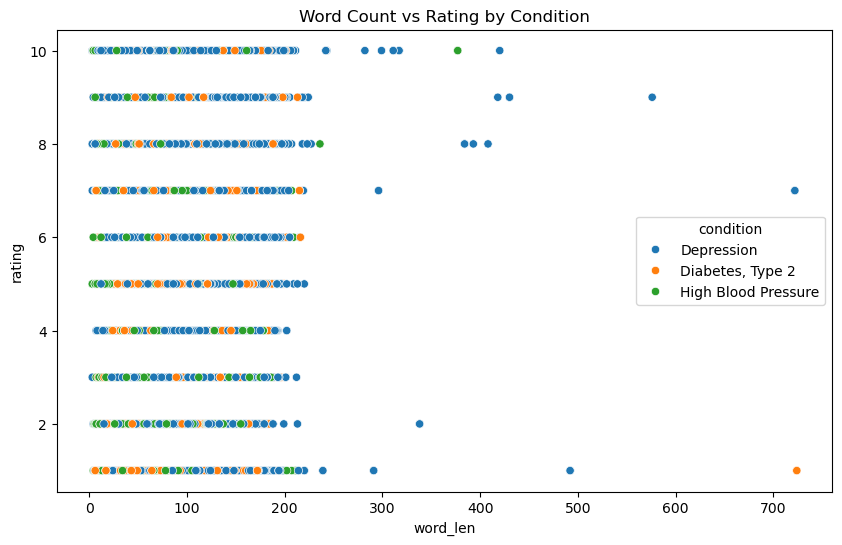

In [51]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_condt, x='word_len', y='rating', hue='condition')
plt.title("Word Count vs Rating by Condition")
plt.show()

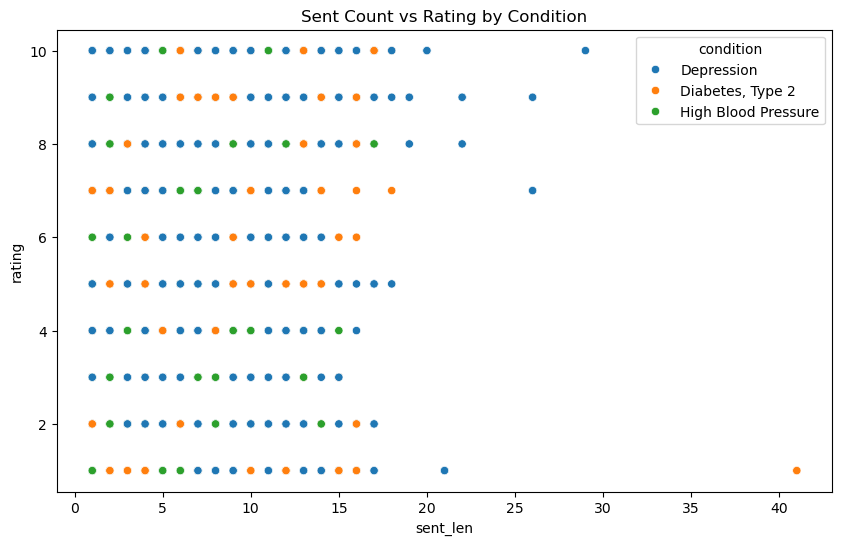

In [52]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_condt, x='sent_len', y='rating', hue='condition')
plt.title("Sent Count vs Rating by Condition")
plt.show()

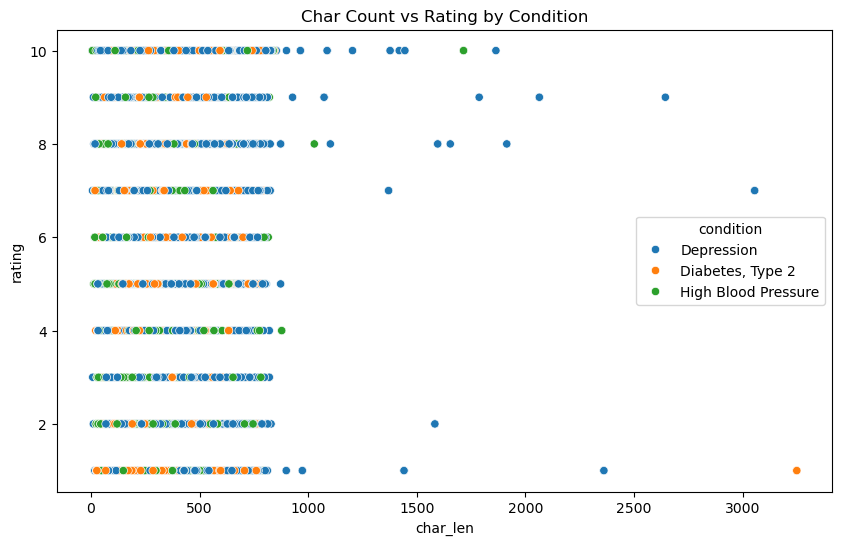

In [53]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_condt, x='char_len', y='rating', hue='condition')
plt.title("Char Count vs Rating by Condition")
plt.show()

C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\218841152.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_condt['date'] = pd.to_datetime(df_condt['date'],errors='coerce')
C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\218841152.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_condt['year'] = df_condt['date'].dt.year
C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\218841152.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

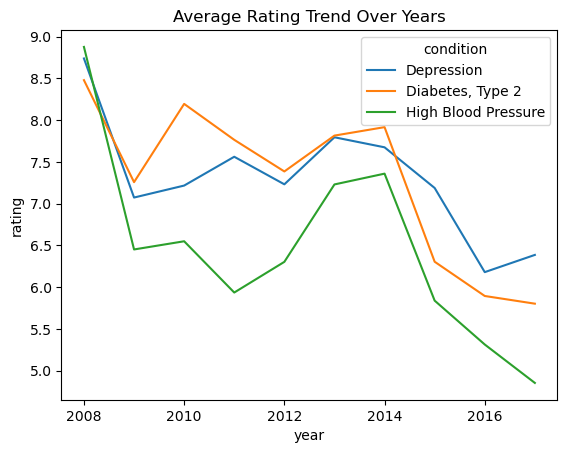

In [54]:
#convert date to datetime 
df_condt['date'] = pd.to_datetime(df_condt['date'],errors='coerce')

#extract date &time
df_condt['year'] = df_condt['date'].dt.year
df_condt['month'] = df_condt['date'].dt.month

#trend over years
trend = df_condt.groupby(['condition','year'])['rating'].mean().reset_index()
sns.lineplot(data=trend,x='year',y='rating',hue='condition')
plt.title("Average Rating Trend Over Years")
plt.show()

#### 8.Insights

C:\Users\NEHA\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\NEHA\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\NEHA\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\NEHA\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

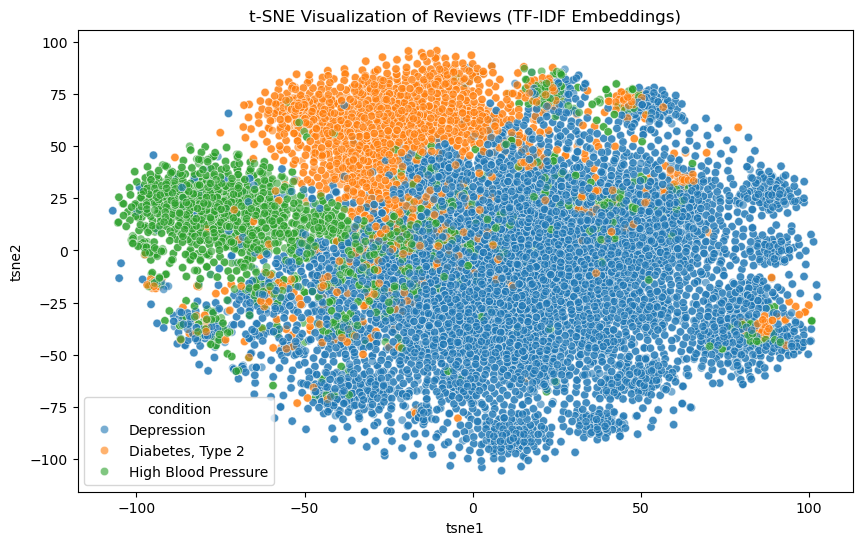

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# TF-IDF embeddings
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df_condt['review'].astype(str))

# Reduce dimensions with PCA
pca = PCA(n_components=50).fit_transform(X.toarray())

# t-SNE projection
tsne = TSNE(n_components=2, random_state=42).fit_transform(pca)

df_condt['tsne1'] = tsne[:,0]
df_condt['tsne2'] = tsne[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_condt, x='tsne1', y='tsne2', hue='condition', alpha=0.6)
plt.title("t-SNE Visualization of Reviews (TF-IDF Embeddings)")
plt.show()

### Model Building

In [56]:
df_condt.head()

,drugName,condition,review,rating,date,processed_tokens,processed_text,char_len,word_len,sent_len,sentiment_score,sentiment_class,year,month,tsne1,tsne2
11,L-methylfolate,Depression,"""I have taken anti-depressants for years, with...",10,2017-03-09,"[taken, antidepressant, year, improvement, mos...",taken antidepressant year improvement mostly m...,456,94,6,0.5994,Positive,2017,3,82.567337,43.476017
31,Sertraline,Depression,"""1 week on Zoloft for anxiety and mood swings....",8,2011-05-07,"[1, week, zoloft, anxiety, mood, swing, take, ...",1 week zoloft anxiety mood swing take 50mg mor...,271,58,5,0.2960,Positive,2011,5,5.420788,43.637913
44,Venlafaxine,Depression,"""my gp started me on Venlafaxine yesterday to ...",4,2016-04-27,"[gp, started, venlafaxine, yesterday, help, de...",gp started venlafaxine yesterday help depressi...,711,155,2,-0.6908,Negative,2016,4,14.321251,0.204198
50,Dulaglutide,"Diabetes, Type 2","""Hey Guys, It&#039;s been 4 months since my l...",10,2017-10-24,"[hey, guy, it039s, 4, month, since, last, post...",hey guy it039s 4 month since last post wanted ...,767,175,7,0.3400,Positive,2017,10,-22.810022,44.865009
67,Effexor XR,Depression,"""This medicine saved my life. I was at my wits...",10,2013-06-20,"[medicine, saved, life, wit, end, antidepressa...",medicine saved life wit end antidepressant rea...,568,119,8,0.8101,Positive,2013,6,27.853558,-49.288933


In [95]:
#create sentiment from ratings
def rating_to_sentiment(r):
    if r >= 7:
      return 'Positive'
    elif r >= 4:
      return 'Neutral'
    else:
      return 'Negative'
        
df_condt['Sentiment Label'] = df_condt['rating'].apply(rating_to_sentiment)
df_condt['Sentiment Label'].drop_duplicates()
df_condt['Sentiment Label'].value_counts()

C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\1021011193.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_condt['Sentiment Label'] = df_condt['rating'].apply(rating_to_sentiment)


Sentiment Label
Positive    9021
Negative    3029
Neutral     1894
Name: count, dtype: int64

In [96]:
# Conditions are encoded into numerical labels for supervised learning
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_condt['condition_label'] = le.fit_transform(df_condt['condition'])

df_condt[['condition', 'condition_label']].drop_duplicates()
df_condt[['condition', 'condition_label']].value_counts()

C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\3657358928.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_condt['condition_label'] = le.fit_transform(df_condt['condition'])


condition            condition_label
Depression           0                  9069
Diabetes, Type 2     1                  2554
High Blood Pressure  2                  2321
Name: count, dtype: int64

In [97]:
from sklearn.preprocessing import LabelEncoder

le_sent = LabelEncoder()

df_condt['sentiment_encoded'] = le_sent.fit_transform(df_condt['Sentiment Label'])

C:\Users\NEHA\AppData\Local\Temp\ipykernel_12136\1091631189.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_condt['sentiment_encoded'] = le_sent.fit_transform(df_condt['Sentiment Label'])


In [98]:
#train test split
x = df_condt['processed_text']

#sentiment target
y_sentiment = df_condt['sentiment_encoded']

#disease target
y_disease = df_condt['condition_label']

In [99]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train_s, y_test_s, y_train_d, y_test_d = train_test_split(
    x, y_sentiment, y_disease,
    test_size=0.2,
    random_state=42,
    stratify=y_sentiment
)

In [100]:
x.shape, y_train_s.shape , y_train_d.shape

((13944,), (11155,), (11155,))

In [105]:
#TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=8000)

x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

In [106]:
#train models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "NaiveBayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(eval_metric='mlogloss'),
    "KNN": KNeighborsClassifier()
}

from sklearn.metrics import accuracy_score, f1_score

results = []

for name, model in models.items():
    model.fit(x_train_vec, y_train_s)
    preds = model.predict(x_test_vec)
    
    acc = accuracy_score(y_test_s, preds)
    f1 = f1_score(y_test_s, preds, average='macro')
    
    results.append([name, acc, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Macro_F1"])
results_df.sort_values(by="Macro_F1", ascending=False)

,Model,Accuracy,Macro_F1
3,RandomForest,0.831122,0.741937
2,SVM,0.831839,0.733621
4,XGBoost,0.793474,0.657276
0,Logistic,0.780567,0.603286
5,KNN,0.540337,0.493650
1,NaiveBayes,0.717820,0.441076


<Axes: >

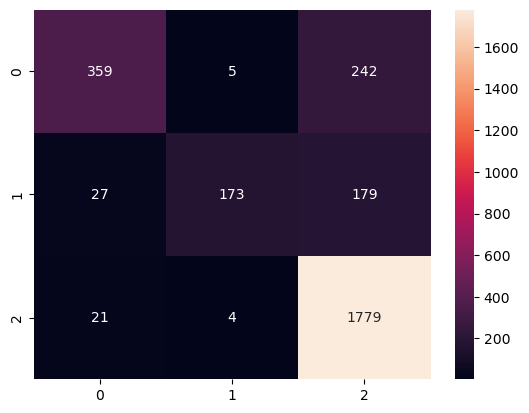

In [108]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

rf = RandomForestClassifier(n_estimators=100)
rf.fit(x_train_vec, y_train_s)
preds = rf.predict(x_test_vec)

cm = confusion_matrix(y_test_s, preds)
sns.heatmap(cm, annot=True, fmt='d')

In [109]:
from sklearn.metrics import classification_report
print(classification_report(y_test_s, preds))

              precision    recall  f1-score   support

           0       0.88      0.59      0.71       606
           1       0.95      0.46      0.62       379
           2       0.81      0.99      0.89      1804

    accuracy                           0.83      2789
   macro avg       0.88      0.68      0.74      2789
weighted avg       0.84      0.83      0.81      2789



In [123]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 40]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, scoring='f1_macro')
grid.fit(x_train_vec, y_train_s)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'n_estimators': 100}
0.6709395956075497


In [111]:
#disease
models_disease = {
    "Logistic": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC(),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(eval_metric='mlogloss'),
    "NaiveBayes": MultinomialNB()
}

results_disease = []

for name, model in models_disease.items():
    model.fit(x_train_vec, y_train_d)
    preds = model.predict(x_test_vec)
    
    acc = accuracy_score(y_test_d, preds)
    f1 = f1_score(y_test_d, preds, average='macro')
    
    results_disease.append([name, acc, f1])

results_disease_df = pd.DataFrame(results_disease, 
                                  columns=["Model", "Accuracy", "Macro_F1"])

results_disease_df.sort_values(by="Macro_F1", ascending=False)

,Model,Accuracy,Macro_F1
1,SVM,0.965579,0.951485
3,XGBoost,0.955898,0.940667
2,RandomForest,0.955540,0.939496
0,Logistic,0.949444,0.930670
4,NaiveBayes,0.936536,0.913040


<Axes: >

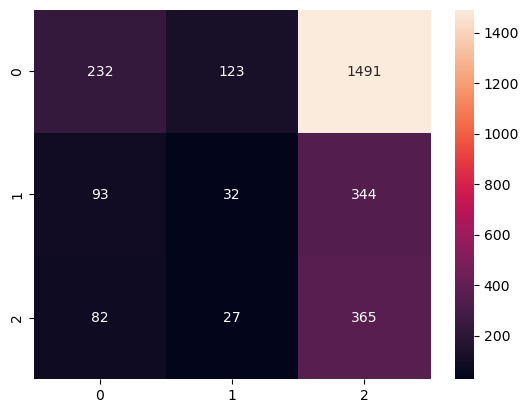

In [114]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

vc = LinearSVC()
vc.fit(x_train_vec, y_train_d)
preds = rf.predict(x_test_vec)

cm = confusion_matrix(y_test_d, preds)
sns.heatmap(cm, annot=True, fmt='d')

In [115]:
from sklearn.metrics import classification_report
print(classification_report(y_test_d, preds))

              precision    recall  f1-score   support

           0       0.57      0.13      0.21      1846
           1       0.18      0.07      0.10       469
           2       0.17      0.77      0.27       474

    accuracy                           0.23      2789
   macro avg       0.30      0.32      0.19      2789
weighted avg       0.44      0.23      0.20      2789



In [118]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced'],
    'max_iter': [2000]
}

grid = GridSearchCV(
    LinearSVC(),
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(x_train_vec, y_train_d)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 1, 'class_weight': 'balanced', 'max_iter': 2000}
Best Score: 0.9436360352096068


In [120]:
# Final Sentiment Model
best_sentiment_model = RandomForestClassifier(n_estimators=100)
best_sentiment_model.fit(x_train_vec, y_train_s)

RandomForestClassifier()

In [121]:
# Final Disease Model
best_disease_model = LinearSVC()
best_disease_model.fit(x_train_vec, y_train_d)

LinearSVC()

In [122]:
#pickel
import joblib
joblib.dump(best_sentiment_model, "sentiment_model.pkl")
joblib.dump(best_disease_model, "disease_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
print("Model and artifacts saved successfully.")

Model and artifacts saved successfully.
